In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error, log_loss
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau
import joblib
import pyttsx3
import os
import re
from math import sqrt

In [2]:
# Define dataset paths and output folder
dataset_paths = [
    r"C:\DATA1\symptom_dataset\symptom_disease_dataset_balanced.csv",
    r"C:\DATA1\symptom_dataset\symptom_disease_dataset_imbalanced.csv",
    r"C:\DATA1\symptom_dataset\symptom_disease_dataset_large.csv"
]
dataset_names = ['Balanced (1000 samples)', 'Imbalanced (5000 samples)', 'Large Diverse (10000 samples)']
output_folder = r"C:\DATA1\symptom_dataset\models"

# Create output folder and verify
try:
    os.makedirs(output_folder, exist_ok=True)
    print(f"Output folder created or exists: {output_folder}")
except Exception as e:
    print(f"Error creating output folder {output_folder}: {e}")
    raise

# Verify dataset directory exists
dataset_dir = r"C:\DATA1\symptom_dataset"
if not os.path.exists(dataset_dir):
    print(f"Dataset directory {dataset_dir} does not exist. Please create it and add datasets.")
    raise FileNotFoundError(f"Directory {dataset_dir} not found")

Output folder created or exists: C:\DATA1\symptom_dataset\models


In [8]:

# Visualize data distribution (for Large Diverse dataset only)
def visualize_data_distribution(data, dataset_id):
    symptom_columns = ['Fever', 'Cough', 'Sneezing', 'Fatigue', 'Loss of Taste', 'Itchy Eyes']
    prevalence = data.groupby('Diagnosis')[symptom_columns].mean()
    
    # Symptom prevalence plot
    plt.figure(figsize=(12, 6))
    prevalence.plot(kind='bar', stacked=False)
    plt.title(f'Symptom Prevalence by Diagnosis - {dataset_id}')
    plt.xlabel('Diagnosis')
    plt.ylabel('Mean Prevalence')
    plt.legend(title='Symptoms')
    plt.tight_layout()
    try:
        plt.savefig(os.path.join(output_folder, f'symptom_prevalence_{dataset_id}.png'))
        print(f"Saved symptom prevalence plot to {os.path.join(output_folder, f'symptom_prevalence_{dataset_id}.png')}")
    except Exception as e:
        print(f"Error saving symptom prevalence plot: {e}")
    plt.show()
    
    # Diagnosis distribution plot
    diagnosis_counts = data['Diagnosis'].value_counts()
    plt.figure(figsize=(8, 8))
    plt.pie(diagnosis_counts, labels=diagnosis_counts.index, autopct='%1.1f%%', startangle=140)
    plt.title(f'Diagnosis Distribution - {dataset_id}')
    plt.tight_layout()
    try:
        plt.savefig(os.path.join(output_folder, f'diagnosis_distribution_{dataset_id}.png'))
        print(f"Saved diagnosis distribution plot to {os.path.join(output_folder, f'diagnosis_distribution_{dataset_id}.png')}")
    except Exception as e:
        print(f"Error saving diagnosis distribution plot: {e}")
    plt.show()

# Function to compute MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero = y_true != 0
    if np.sum(non_zero) == 0:
        return np.nan
    return np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100


In [3]:
# Function to train and evaluate Random Forest
def train_rf(X_train, X_test, y_train, y_test, y_test_one_hot, dataset_id):
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    rf_pred_probs = rf_model.predict_proba(X_test)
    rf_accuracy = accuracy_score(y_test, rf_pred)
    rf_f1 = f1_score(y_test, rf_pred, average='weighted')
    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_mse = mean_squared_error(y_test, rf_pred)
    rf_rmse = sqrt(rf_mse)
    rf_mape = mean_absolute_percentage_error(y_test, rf_pred)
    rf_loss = log_loss(y_test, rf_pred_probs)
    
    try:
        joblib.dump(rf_model, os.path.join(output_folder, f'rf_model_{dataset_id}.pkl'))
        print(f"Saved Random Forest model to {os.path.join(output_folder, f'rf_model_{dataset_id}.pkl')}")
    except Exception as e:
        print(f"Error saving Random Forest model for {dataset_id}: {e}")
        raise
    return rf_model, rf_accuracy, rf_f1, rf_mae, rf_mse, rf_rmse, rf_mape, rf_loss

In [4]:
# Function to train and evaluate Fully Connected Neural Network
def train_fc(X_train_dl, X_test_dl, y_train_dl, y_test, y_test_one_hot, X, label_encoder, dataset_id):
    def build_fc_model():
        inputs = tf.keras.Input(shape=(X.shape[1],))
        x = layers.Dense(64, activation='relu')(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x, training=True)
        x = layers.Dense(32, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x, training=True)
        x = layers.Dense(16, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x, training=True)
        outputs = layers.Dense(len(label_encoder.classes_), activation='softmax')(x)
        return tf.keras.Model(inputs, outputs)
    
    fc_model = build_fc_model()
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    fc_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    history = fc_model.fit(X_train_dl, y_train_dl, epochs=50, batch_size=32, verbose=1, 
                          validation_split=0.2, callbacks=[lr_scheduler])
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'FCNN Loss - {dataset_id}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'FCNN Accuracy - {dataset_id}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    try:
        plt.savefig(os.path.join(output_folder, f'fcnn_training_plot_{dataset_id}.png'))
        print(f"Saved FCNN training plot to {os.path.join(output_folder, f'fcnn_training_plot_{dataset_id}.png')}")
    except Exception as e:
        print(f"Error saving FCNN training plot for {dataset_id}: {e}")
    plt.show()
    
    fc_pred_probs = fc_model.predict(X_test_dl, verbose=0)
    fc_pred = np.argmax(fc_pred_probs, axis=1)
    fc_accuracy = accuracy_score(y_test, fc_pred)
    fc_f1 = f1_score(y_test, fc_pred, average='weighted')
    fc_mae = mean_absolute_error(y_test, fc_pred)
    fc_mse = mean_squared_error(y_test, fc_pred)
    fc_rmse = sqrt(fc_mse)
    fc_mape = mean_absolute_percentage_error(y_test, fc_pred)
    fc_loss = log_loss(y_test, fc_pred_probs)
    
    try:
        fc_model.save(os.path.join(output_folder, f'fc_model_{dataset_id}.h5'))
        print(f"Saved Fully Connected model to {os.path.join(output_folder, f'fc_model_{dataset_id}.h5')}")
    except Exception as e:
        print(f"Error saving Fully Connected model for {dataset_id}: {e}")
        raise
    return fc_model, fc_accuracy, fc_f1, fc_mae, fc_mse, fc_rmse, fc_mape, fc_loss, history

In [5]:
# Function to train and evaluate RNN
def train_rnn(X_train_rnn, X_test_rnn, y_train_dl, y_test, y_test_one_hot, label_encoder, dataset_id):
    def build_rnn_model():
        inputs = tf.keras.Input(shape=(6, 1))
        x = layers.LSTM(32, activation='relu', return_sequences=False)(inputs)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(len(label_encoder.classes_), activation='softmax')(x)
        return tf.keras.Model(inputs, outputs)
    
    rnn_model = build_rnn_model()
    rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = rnn_model.fit(X_train_rnn, y_train_dl, epochs=50, batch_size=32, verbose=1, validation_split=0.2)
    
    # Plot RNN training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'RNN Loss - {dataset_id}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'RNN Accuracy - {dataset_id}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    try:
        plt.savefig(os.path.join(output_folder, f'rnn_training_plot_{dataset_id}.png'))
        print(f"Saved RNN training plot to {os.path.join(output_folder, f'rnn_training_plot_{dataset_id}.png')}")
    except Exception as e:
        print(f"Error saving RNN training plot for {dataset_id}: {e}")
    plt.show()
    
    rnn_pred_probs = rnn_model.predict(X_test_rnn, verbose=0)
    rnn_pred = np.argmax(rnn_pred_probs, axis=1)
    rnn_accuracy = accuracy_score(y_test, rnn_pred)
    rnn_f1 = f1_score(y_test, rnn_pred, average='weighted')
    rnn_mae = mean_absolute_error(y_test, rnn_pred)
    rnn_mse = mean_squared_error(y_test, rnn_pred)
    rnn_rmse = sqrt(rnn_mse)
    rnn_mape = mean_absolute_percentage_error(y_test, rnn_pred)
    rnn_loss = log_loss(y_test, rnn_pred_probs)
    
    try:
        rnn_model.save(os.path.join(output_folder, f'rnn_model_{dataset_id}.h5'))
        print(f"Saved RNN model to {os.path.join(output_folder, f'rnn_model_{dataset_id}.h5')}")
    except Exception as e:
        print(f"Error saving RNN model for {dataset_id}: {e}")
        raise
    return rnn_model, rnn_accuracy, rnn_f1, rnn_mae, rnn_mse, rnn_rmse, rnn_mape, rnn_loss


In [6]:
# Function to plot model comparison
def plot_model_comparison(results, dataset_id, metrics=['Accuracy', 'F1-Score', 'MAE', 'MSE', 'RMSE', 'MAPE', 'Loss']):
    plt.figure(figsize=(12, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(2, 4, i+1)
        sns.barplot(x='Model', y=metric, data=results)
        plt.title(f'{metric} Comparison')
        plt.ylabel(metric)
        plt.xticks(rotation=45)
    plt.tight_layout()
    try:
        plt.savefig(os.path.join(output_folder, f'model_metrics_comparison_{dataset_id}.png'))
        print(f"Saved model metrics comparison plot to {os.path.join(output_folder, f'model_metrics_comparison_{dataset_id}.png')}")
    except Exception as e:
        print(f"Error saving model metrics comparison plot: {e}")
    plt.show()

# Function to parse symptoms from text
def parse_symptoms(text):
    symptom_map = {
        'Fever': ['fever', 'high temperature', 'hot'],
        'Cough': ['cough', 'coughing'],
        'Sneezing': ['sneeze', 'sneezing'],
        'Fatigue': ['fatigue', 'tired', 'exhausted'],
        'Loss of Taste': ['loss of taste', 'no taste', 'taste loss', 'lost my sense of taste'],
        'Itchy Eyes': ['itchy eyes', 'eye itch', 'eyes itching']
    }
    symptoms = [0] * 6  # [Fever, Cough, Sneezing, Fatigue, Loss of Taste, Itchy Eyes]
    text = text.lower()
    
    for i, (symptom, keywords) in enumerate(symptom_map.items()):
        for keyword in keywords:
            if keyword in text:
                symptoms[i] = 1
                print(f"Matched symptom '{symptom}' with keyword '{keyword}'")
                break
    
    return symptoms


Processing Balanced (1000 samples)...
Saved Random Forest model to C:\DATA1\symptom_dataset\models\rf_model_balanced_1000_samples.pkl
Epoch 1/50
20/20 [==============================] - 1s 13ms/step - loss: 1.7549 - accuracy: 0.2516 - val_loss: 1.3600 - val_accuracy: 0.3438 - lr: 5.0000e-04
Epoch 2/50
20/20 [==============================] - 0s 3ms/step - loss: 1.5834 - accuracy: 0.3031 - val_loss: 1.3470 - val_accuracy: 0.4000 - lr: 5.0000e-04
Epoch 3/50
20/20 [==============================] - 0s 3ms/step - loss: 1.5087 - accuracy: 0.3516 - val_loss: 1.3767 - val_accuracy: 0.3688 - lr: 5.0000e-04
Epoch 4/50
20/20 [==============================] - 0s 4ms/step - loss: 1.4299 - accuracy: 0.3922 - val_loss: 1.3506 - val_accuracy: 0.3500 - lr: 5.0000e-04
Epoch 5/50
20/20 [==============================] - 0s 3ms/step - loss: 1.3317 - accuracy: 0.4109 - val_loss: 1.3467 - val_accuracy: 0.3500 - lr: 5.0000e-04
Epoch 6/50
20/20 [==============================] - 0s 3ms/step - loss: 1.3176 

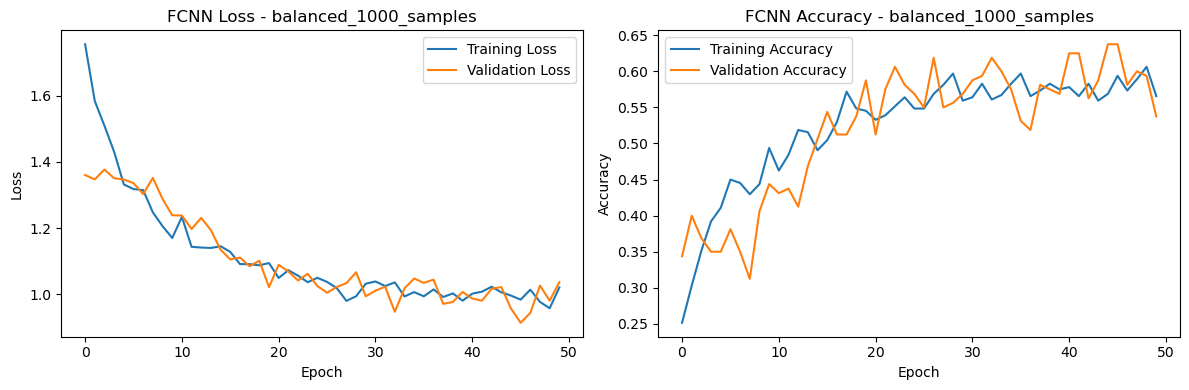

Saved Fully Connected model to C:\DATA1\symptom_dataset\models\fc_model_balanced_1000_samples.h5
Epoch 1/50
20/20 [==============================] - 1s 11ms/step - loss: 1.3872 - accuracy: 0.2328 - val_loss: 1.3836 - val_accuracy: 0.2375
Epoch 2/50
20/20 [==============================] - 0s 3ms/step - loss: 1.3840 - accuracy: 0.2828 - val_loss: 1.3817 - val_accuracy: 0.2438
Epoch 3/50
20/20 [==============================] - 0s 3ms/step - loss: 1.3810 - accuracy: 0.2828 - val_loss: 1.3791 - val_accuracy: 0.2688
Epoch 4/50
20/20 [==============================] - 0s 3ms/step - loss: 1.3790 - accuracy: 0.2922 - val_loss: 1.3753 - val_accuracy: 0.2688
Epoch 5/50
20/20 [==============================] - 0s 3ms/step - loss: 1.3745 - accuracy: 0.3172 - val_loss: 1.3682 - val_accuracy: 0.3375
Epoch 6/50
20/20 [==============================] - 0s 3ms/step - loss: 1.3643 - accuracy: 0.3438 - val_loss: 1.3569 - val_accuracy: 0.3438
Epoch 7/50
20/20 [==============================] - 0s 3ms/ste

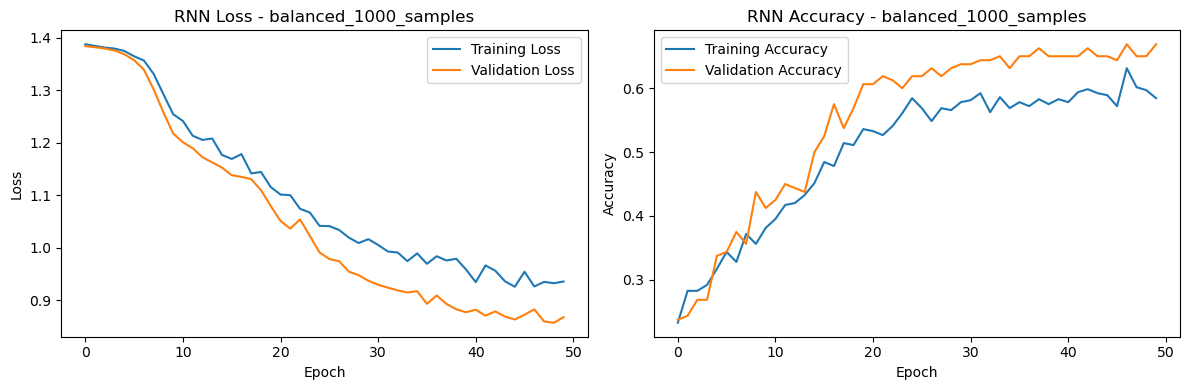

Saved RNN model to C:\DATA1\symptom_dataset\models\rnn_model_balanced_1000_samples.h5
Saved label encoder to C:\DATA1\symptom_dataset\models\label_encoder_balanced_1000_samples.pkl
Saved model metrics comparison plot to C:\DATA1\symptom_dataset\models\model_metrics_comparison_balanced_1000_samples.png


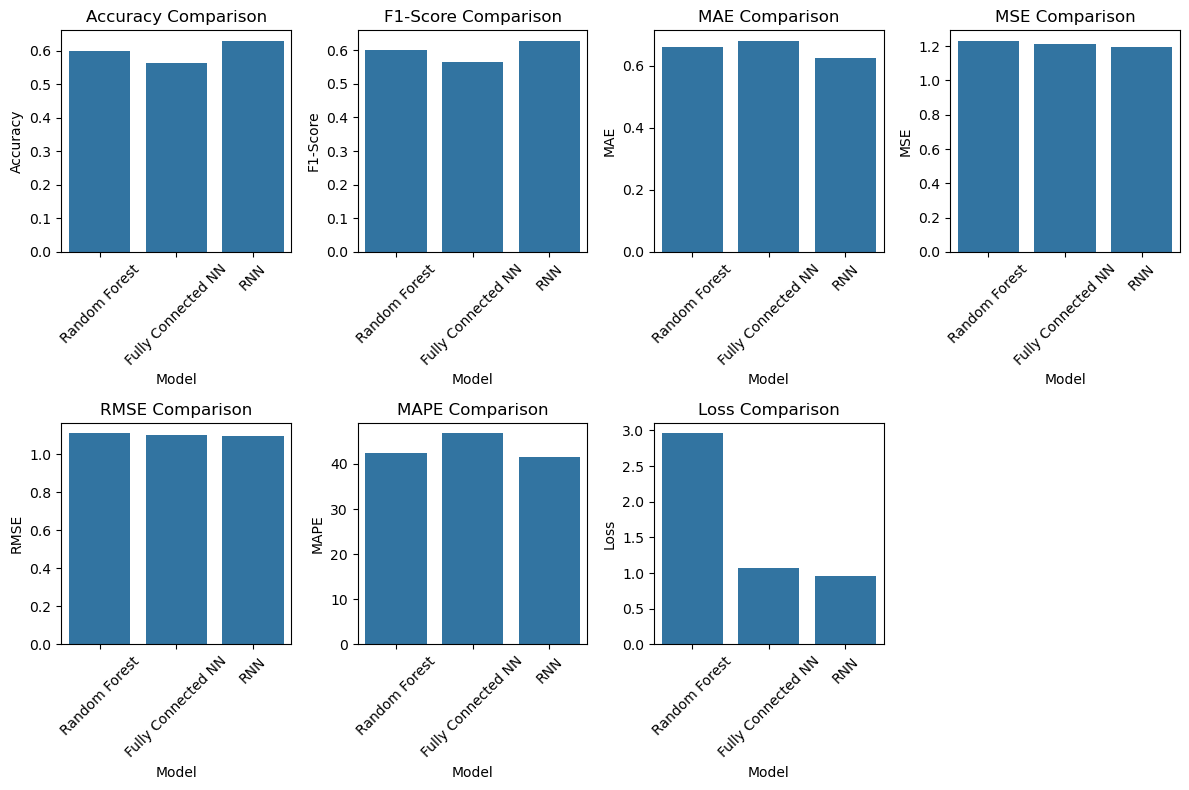


Model Comparison for Balanced (1000 samples):
                Model  Accuracy  F1-Score    MAE    MSE      RMSE       MAPE  \
0       Random Forest     0.600  0.600270  0.660  1.230  1.109054  42.393736   
1  Fully Connected NN     0.565  0.564057  0.680  1.210  1.100000  46.756152   
2                 RNN     0.630  0.627257  0.625  1.195  1.093161  41.610738   

       Loss  
0  2.957998  
1  1.076136  
2  0.953857  

Processing Imbalanced (5000 samples)...
Saved Random Forest model to C:\DATA1\symptom_dataset\models\rf_model_imbalanced_5000_samples.pkl
Epoch 1/50
100/100 [==============================] - 1s 3ms/step - loss: 1.7467 - accuracy: 0.3331 - val_loss: 1.3736 - val_accuracy: 0.2962 - lr: 5.0000e-04
Epoch 2/50
100/100 [==============================] - 0s 2ms/step - loss: 1.3178 - accuracy: 0.4616 - val_loss: 1.2885 - val_accuracy: 0.3725 - lr: 5.0000e-04
Epoch 3/50
100/100 [==============================] - 0s 1ms/step - loss: 1.2107 - accuracy: 0.5197 - val_loss: 1.1855 

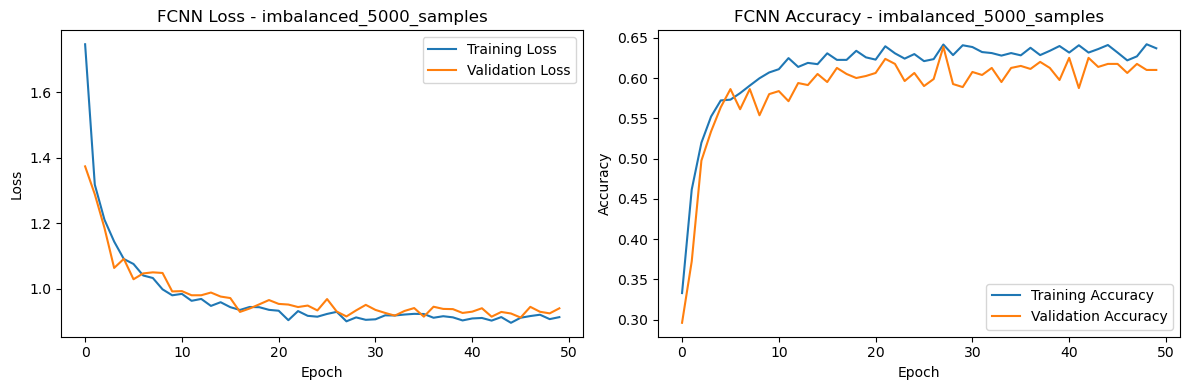

Saved Fully Connected model to C:\DATA1\symptom_dataset\models\fc_model_imbalanced_5000_samples.h5
Epoch 1/50
100/100 [==============================] - 1s 4ms/step - loss: 1.3176 - accuracy: 0.3969 - val_loss: 1.2636 - val_accuracy: 0.4062
Epoch 2/50
100/100 [==============================] - 0s 2ms/step - loss: 1.2472 - accuracy: 0.3941 - val_loss: 1.2334 - val_accuracy: 0.4150
Epoch 3/50
100/100 [==============================] - 0s 3ms/step - loss: 1.2168 - accuracy: 0.4144 - val_loss: 1.1912 - val_accuracy: 0.4437
Epoch 4/50
100/100 [==============================] - 0s 2ms/step - loss: 1.1898 - accuracy: 0.4378 - val_loss: 1.1724 - val_accuracy: 0.4775
Epoch 5/50
100/100 [==============================] - 0s 2ms/step - loss: 1.1478 - accuracy: 0.4863 - val_loss: 1.1160 - val_accuracy: 0.4988
Epoch 6/50
100/100 [==============================] - 0s 2ms/step - loss: 1.0988 - accuracy: 0.5344 - val_loss: 1.0821 - val_accuracy: 0.5400
Epoch 7/50
100/100 [=============================

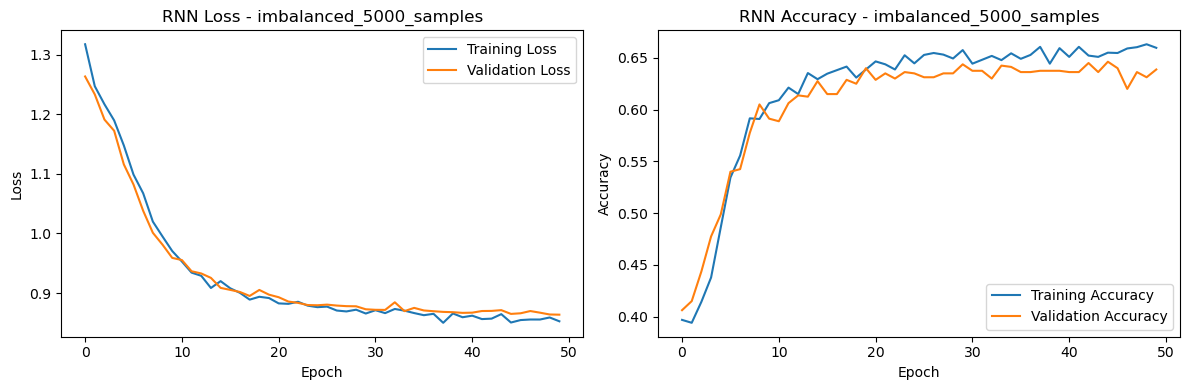

Saved RNN model to C:\DATA1\symptom_dataset\models\rnn_model_imbalanced_5000_samples.h5
Saved label encoder to C:\DATA1\symptom_dataset\models\label_encoder_imbalanced_5000_samples.pkl
Saved model metrics comparison plot to C:\DATA1\symptom_dataset\models\model_metrics_comparison_imbalanced_5000_samples.png


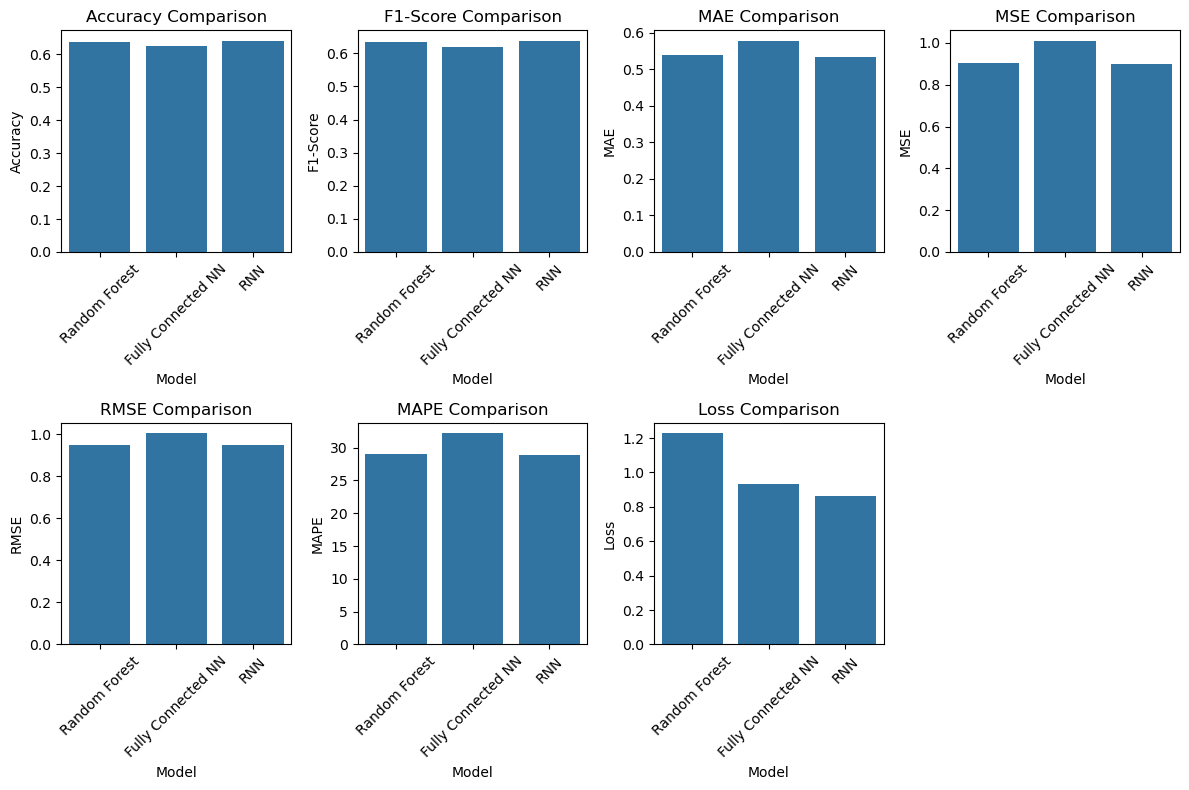


Model Comparison for Imbalanced (5000 samples):
                Model  Accuracy  F1-Score    MAE    MSE      RMSE       MAPE  \
0       Random Forest     0.638  0.634712  0.538  0.902  0.949737  29.000000   
1  Fully Connected NN     0.625  0.618301  0.578  1.010  1.004988  32.166667   
2                 RNN     0.641  0.637621  0.535  0.899  0.948156  28.851852   

       Loss  
0  1.227200  
1  0.932434  
2  0.865898  

Processing Large Diverse (10000 samples)...
Saved symptom prevalence plot to C:\DATA1\symptom_dataset\models\symptom_prevalence_large_diverse_10000_samples.png


<Figure size 1200x600 with 0 Axes>

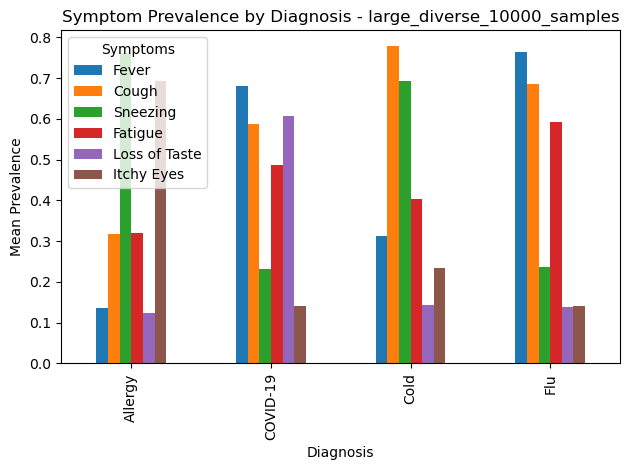

Saved diagnosis distribution plot to C:\DATA1\symptom_dataset\models\diagnosis_distribution_large_diverse_10000_samples.png


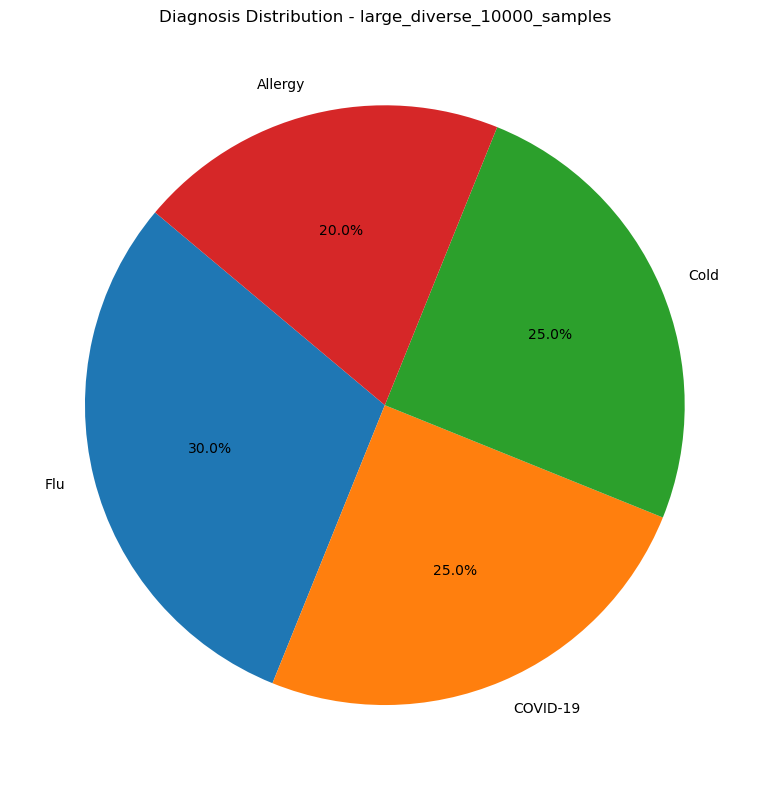

Saved Random Forest model to C:\DATA1\symptom_dataset\models\rf_model_large_diverse_10000_samples.pkl
Epoch 1/50
200/200 [==============================] - 1s 2ms/step - loss: 1.6292 - accuracy: 0.3597 - val_loss: 1.3190 - val_accuracy: 0.4050 - lr: 5.0000e-04
Epoch 2/50
200/200 [==============================] - 0s 2ms/step - loss: 1.2961 - accuracy: 0.4680 - val_loss: 1.2085 - val_accuracy: 0.4787 - lr: 5.0000e-04
Epoch 3/50
200/200 [==============================] - 0s 2ms/step - loss: 1.1989 - accuracy: 0.5033 - val_loss: 1.1486 - val_accuracy: 0.5231 - lr: 5.0000e-04
Epoch 4/50
200/200 [==============================] - 0s 2ms/step - loss: 1.1683 - accuracy: 0.5205 - val_loss: 1.1178 - val_accuracy: 0.5300 - lr: 5.0000e-04
Epoch 5/50
200/200 [==============================] - 0s 2ms/step - loss: 1.1152 - accuracy: 0.5394 - val_loss: 1.0983 - val_accuracy: 0.5519 - lr: 5.0000e-04
Epoch 6/50
200/200 [==============================] - 0s 2ms/step - loss: 1.0838 - accuracy: 0.5456 - v

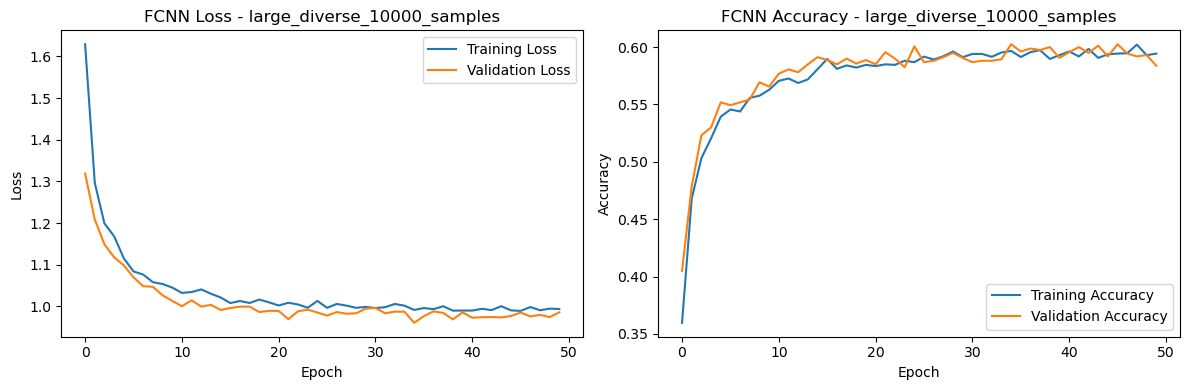

Saved Fully Connected model to C:\DATA1\symptom_dataset\models\fc_model_large_diverse_10000_samples.h5
Epoch 1/50
200/200 [==============================] - 1s 3ms/step - loss: 1.3493 - accuracy: 0.3170 - val_loss: 1.2743 - val_accuracy: 0.3944
Epoch 2/50
200/200 [==============================] - 0s 2ms/step - loss: 1.2390 - accuracy: 0.4267 - val_loss: 1.1857 - val_accuracy: 0.5138
Epoch 3/50
200/200 [==============================] - 0s 2ms/step - loss: 1.1656 - accuracy: 0.4830 - val_loss: 1.0871 - val_accuracy: 0.5450
Epoch 4/50
200/200 [==============================] - 0s 2ms/step - loss: 1.1065 - accuracy: 0.5281 - val_loss: 1.0217 - val_accuracy: 0.5775
Epoch 5/50
200/200 [==============================] - 0s 2ms/step - loss: 1.0674 - accuracy: 0.5527 - val_loss: 0.9938 - val_accuracy: 0.5781
Epoch 6/50
200/200 [==============================] - 0s 2ms/step - loss: 1.0380 - accuracy: 0.5666 - val_loss: 0.9850 - val_accuracy: 0.5875
Epoch 7/50
200/200 [=========================

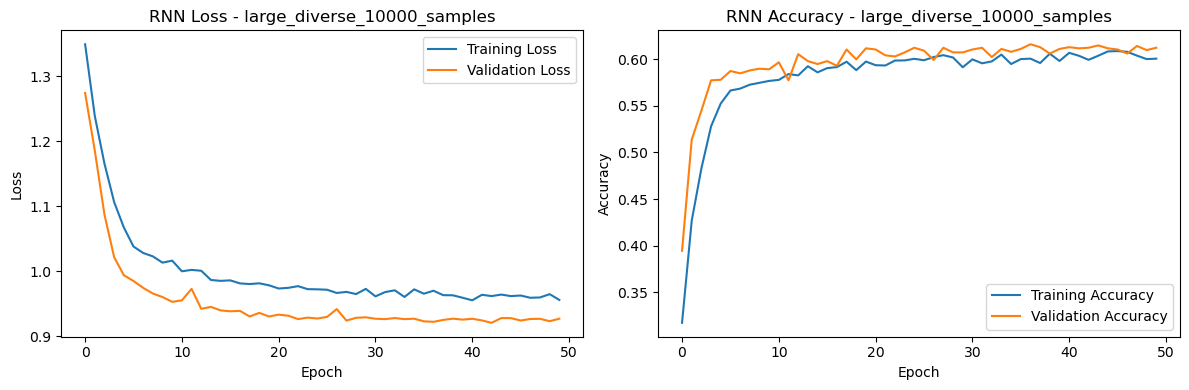

Saved RNN model to C:\DATA1\symptom_dataset\models\rnn_model_large_diverse_10000_samples.h5
Saved label encoder to C:\DATA1\symptom_dataset\models\label_encoder_large_diverse_10000_samples.pkl
Saved model metrics comparison plot to C:\DATA1\symptom_dataset\models\model_metrics_comparison_large_diverse_10000_samples.png


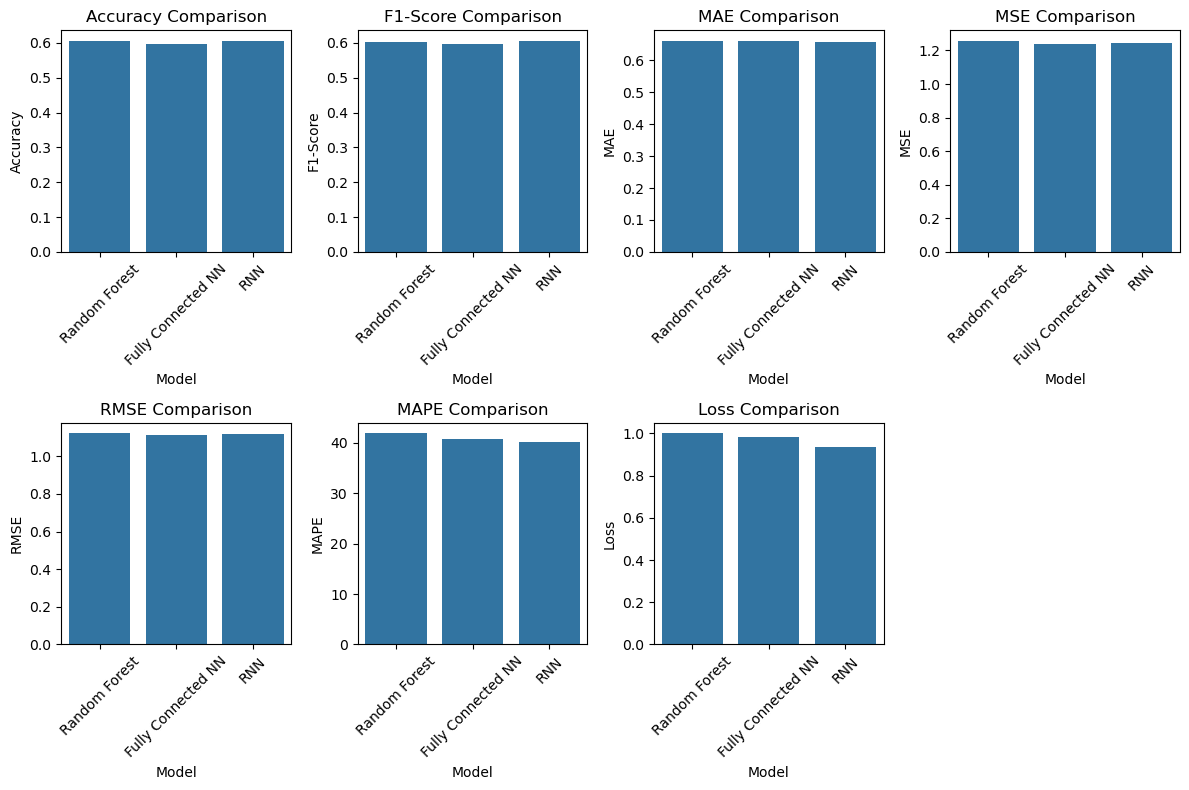


Model Comparison for Large Diverse (10000 samples):
                Model  Accuracy  F1-Score    MAE    MSE      RMSE       MAPE  \
0       Random Forest    0.6045  0.602445  0.660  1.257  1.121160  41.835017   
1  Fully Connected NN    0.5985  0.597730  0.659  1.237  1.112205  40.667088   
2                 RNN    0.6060  0.605560  0.656  1.246  1.116244  40.046296   

       Loss  
0  1.000158  
1  0.984419  
2  0.935832  


In [9]:
# Process each dataset
fc_model_large = None
label_encoder_large = None
for dataset_path, dataset_name in zip(dataset_paths, dataset_names):
    print(f"\nProcessing {dataset_name}...")
    
    # Load and preprocess the dataset
    data = pd.read_csv(dataset_path)
    X = data.drop('Diagnosis', axis=1)
    y = data['Diagnosis']
    
    # Visualize data distribution for Large Diverse dataset
    dataset_id = dataset_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    if dataset_name == 'Large Diverse (10000 samples)':
        visualize_data_distribution(data, dataset_id)
    
    # Encode target labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    y_one_hot = tf.keras.utils.to_categorical(y_encoded)
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
    X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)
    
    # Reshape for RNN
    X_train_rnn = X_train_dl.values.reshape(-1, 6, 1)
    X_test_rnn = X_test_dl.values.reshape(-1, 6, 1)
    
    # Train and evaluate each model
    rf_model, rf_accuracy, rf_f1, rf_mae, rf_mse, rf_rmse, rf_mape, rf_loss = train_rf(
        X_train, X_test, y_train, y_test, y_test_dl, dataset_id)
    fc_model, fc_accuracy, fc_f1, fc_mae, fc_mse, fc_rmse, fc_mape, fc_loss, fc_history = train_fc(
        X_train_dl, X_test_dl, y_train_dl, y_test, y_test_dl, X, label_encoder, dataset_id)
    rnn_model, rnn_accuracy, rnn_f1, rnn_mae, rnn_mse, rnn_rmse, rnn_mape, rnn_loss = train_rnn(
        X_train_rnn, X_test_rnn, y_train_dl, y_test, y_test_dl, label_encoder, dataset_id)
    
    # Save label encoder
    try:
        joblib.dump(label_encoder, os.path.join(output_folder, f'label_encoder_{dataset_id}.pkl'))
        print(f"Saved label encoder to {os.path.join(output_folder, f'label_encoder_{dataset_id}.pkl')}")
    except Exception as e:
        print(f"Error saving label encoder for {dataset_id}: {e}")
        raise
    
    # Store Fully Connected model and label encoder for large dataset
    if dataset_name == 'Large Diverse (10000 samples)':
        fc_model_large = fc_model
        label_encoder_large = label_encoder
    
    # Collect results
    results = pd.DataFrame({
        'Model': ['Random Forest', 'Fully Connected NN', 'RNN'],
        'Accuracy': [rf_accuracy, fc_accuracy, rnn_accuracy],
        'F1-Score': [rf_f1, fc_f1, rnn_f1],
        'MAE': [rf_mae, fc_mae, rnn_mae],
        'MSE': [rf_mse, fc_mse, rnn_mse],
        'RMSE': [rf_rmse, fc_rmse, rnn_rmse],
        'MAPE': [rf_mape, fc_mape, rnn_mape],
        'Loss': [rf_loss, fc_loss, rnn_loss]
    })
    
    # Plot model comparison
    plot_model_comparison(results, dataset_id)
    
    print(f"\nModel Comparison for {dataset_name}:")
    print(results)

     Hello! I am your virtual health assistant robot.
Using RNN model.
Please describe your symptoms (e.g., 'I have a fever and cough') or type 'ask' to answer Y/N questions:
Matched symptom 'Cough' with keyword 'cough'
Matched symptom 'Fatigue' with keyword 'tired'
Matched symptom 'Loss of Taste' with keyword 'lost my sense of taste'

Detected symptoms: ['Cough', 'Fatigue', 'Loss of Taste']
Symptom vector: [0, 1, 0, 1, 1, 0]

     Diagnosis with Probabilities and Uncertainty:
Allergy: P=0.014, Uncertainty=0.012
COVID-19: P=0.623, Uncertainty=0.106
Cold: P=0.130, Uncertainty=0.055
Flu: P=0.234, Uncertainty=0.071

         Diagnosis: COVID-19 (±0.106)
   Test: PCR test
   Medicine: Isolation + Paracetamol


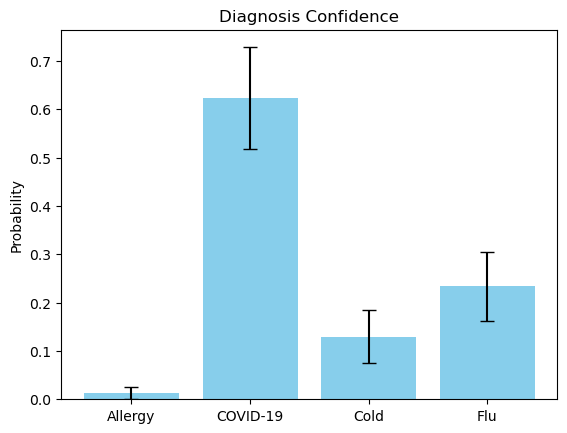

In [10]:
# Speak function
def speak(text):
    try:
        engine = pyttsx3.init()
        engine.say(text)
        engine.runAndWait()
    except Exception as e:
        print(f"Speech error: {e}")

# Prediction with uncertainty
def predict_with_uncertainty(model, x, n_iter=100, is_rnn=False):
    if is_rnn:
        x = x.reshape(-1, 6, 1)
    preds = np.array([model(x, training=True).numpy() for _ in range(n_iter)])
    mean = preds.mean(axis=0)
    std = preds.std(axis=0)
    return mean, std

# Run virtual robot (with option to use RNN)
def run_virtual_robot(use_rnn=False):
    print("     Hello! I am your virtual health assistant robot.")
    print(f"Using {'RNN' if use_rnn else 'Fully Connected NN'} model.")
    print("Please describe your symptoms (e.g., 'I have a fever and cough') or type 'ask' to answer Y/N questions:")
    
    # Load model
    if use_rnn:
        model = tf.keras.models.load_model(os.path.join(output_folder, 'rnn_model_large_diverse_10000_samples.h5'))
    else:
        model = fc_model_large
    
    user_input = input("Your symptoms: ").strip().lower()
    symptom_names = ["Fever", "Cough", "Sneezing", "Fatigue", "Loss of Taste", "Itchy Eyes"]
    input_symptoms = None
    
    if user_input != 'ask':
        input_symptoms = parse_symptoms(user_input)
        if sum(input_symptoms) > 0:
            print("\nDetected symptoms:", [name for i, name in enumerate(symptom_names) if input_symptoms[i] == 1])
            print(f"Symptom vector: {input_symptoms}")
        else:
            print("\nNo symptoms detected in your description. Falling back to Y/N questions.")
            user_input = 'ask'
    
    if user_input == 'ask':
        input_symptoms = []
        print("\nPlease answer the following questions with Y/N:")
        for name in symptom_names:
            ans = input(f"Do you have {name}? (Y/N): ").strip().lower()
            input_symptoms.append(1 if ans == 'y' else 0)
        print(f"Symptom vector: {input_symptoms}")
    
    input_array = np.array([input_symptoms], dtype=np.float32)
    mean_probs, std_probs = predict_with_uncertainty(model, input_array, is_rnn=use_rnn)
    most_likely = np.argmax(mean_probs)
    diagnosis = label_encoder_large.classes_[most_likely]
    
    print("\n     Diagnosis with Probabilities and Uncertainty:")
    for i, dis in enumerate(label_encoder_large.classes_):
        print(f"{dis}: P={mean_probs[0][i]:.3f}, Uncertainty={std_probs[0][i]:.3f}")
    
    speak(f"You may have {diagnosis}.")
    print(f"\n         Diagnosis: {diagnosis} (±{std_probs[0][most_likely]:.3f})")
    
    test_map = {
        "Flu": "Influenza A/B test",
        "Cold": "Nasal swab",
        "COVID-19": "PCR test",
        "Allergy": "Allergy skin test"
    }
    medicine_map = {
        "Flu": "Oseltamivir (Tamiflu)",
        "Cold": "Rest, fluids, antihistamines",
        "COVID-19": "Isolation + Paracetamol",
        "Allergy": "Loratadine or Cetirizine"
    }
    
    speak(f"I recommend you take a {test_map[diagnosis]} and consider taking {medicine_map[diagnosis]}")
    print(f"   Test: {test_map[diagnosis]}")
    print(f"   Medicine: {medicine_map[diagnosis]}")
    
    # Plot
    plt.bar(label_encoder_large.classes_, mean_probs[0], yerr=std_probs[0], capsize=5, color='skyblue')
    plt.ylabel("Probability")
    plt.title("Diagnosis Confidence")
    plt.show()

# Execute virtual robot (default: FCNN)
# run_virtual_robot(use_rnn=False)
# To test RNN, uncomment:
run_virtual_robot(use_rnn=True)